# Regression: Residual Analysis

**Module 6: Correlation Analysis** | Lean Six Sigma Data Analytics

---

## The Four Steps of Regression

Regression analysis consists of four steps:

1. Fitted line plot *(previous video)*
2. Main regression analysis *(previous video)*
3. **Residual analysis** *(this video)*
4. Prediction interval *(next video)*

In this video, we will explain how to perform a **residual check** to validate the results.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for residual analysis!')


Ready for residual analysis!


---

## Recap: Results from Previous Analysis

Remember that we were studying if the number of production stops was an influence factor for the number of broken defect tea bags.

In [2]:
# Load tea bag data and perform regression
def load_teabags():
    df = pd.read_excel(xlsx, sheet_name='Tea bags', skiprows=7)
    return df.dropna()

teabags = load_teabags()

# Perform regression
x = teabags['Stops'].values
y = teabags['Bags'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print('RESULTS FROM PREVIOUS ANALYSIS')
print('=' * 60)
print()
print(f'Regression equation: Bags = {intercept:.2f} + {slope:.2f} * Stops')
print()
print(f'P-value: {p_value:.4f}')
print('  → Results are statistically significant')
print()
print(f'R-squared: {r_squared:.1%}')
print('  → The number of production stops explains a large part')
print('    of the behavior of defect bags')

RESULTS FROM PREVIOUS ANALYSIS

Regression equation: Bags = 6.31 + 1.94 * Stops

P-value: 0.0000
  → Results are statistically significant

R-squared: 89.0%
  → The number of production stops explains a large part
    of the behavior of defect bags


---

## Why Residual Analysis?

These were the first two steps of regression analysis.

**Before we can completely trust our conclusions**, we have to verify the underlying assumptions of regression analysis.

This is called the **residual analysis**.

We have to check:
1. Are the residuals **normally distributed**?
2. Do the residuals show any **outliers or irregularities**?

---

## What is a Residual?

Let's look at the fitted line plot:
- The **dots** represent the data (observed values)
- The **line** represents the fitted values based on the regression equation

There is a **difference** between the data and the fitted value.

> **Residual** = Observed value (data) − Fitted value (regression line)

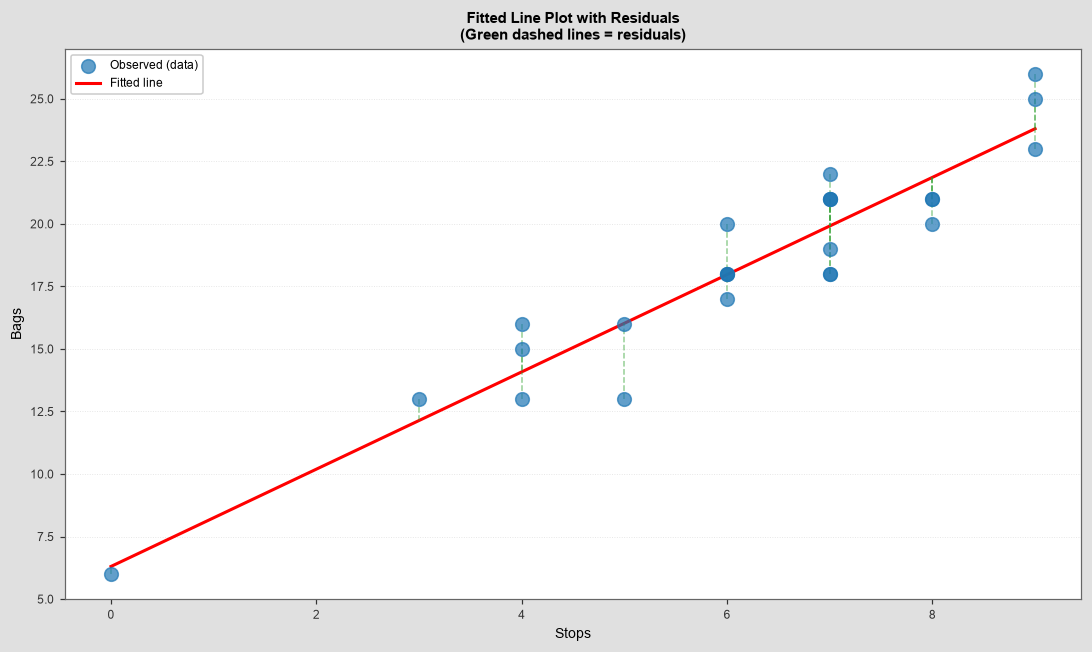

The green dashed lines show the RESIDUALS.
Residual = Observed value - Fitted value


In [3]:
# Visualize residuals
fitted = intercept + slope * x
residuals = y - fitted

fig, ax = plt.subplots(figsize=(10, 6))

# Plot data points
ax.scatter(x, y, s=80, alpha=0.7, label='Observed (data)', zorder=3)

# Plot fitted line
x_line = np.array([x.min(), x.max()])
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, 'r-', linewidth=2, label='Fitted line')

# Show residuals as vertical lines
for xi, yi, fi in zip(x, y, fitted):
    ax.plot([xi, xi], [yi, fi], color=ms.GREEN, linestyle='--', alpha=0.5)

ax.set_xlabel('Stops')
ax.set_ylabel('Bags')
ax.set_title('Fitted Line Plot with Residuals\n(Green dashed lines = residuals)')
ax.legend()

plt.tight_layout()
plt.show()

print('The green dashed lines show the RESIDUALS.')
print('Residual = Observed value - Fitted value')

---

## Performing Residual Analysis in Minitab

In Minitab: **Stat > Regression > Fitted Line Plot**
- Response: Bags
- Predictor: Stops
- **Graphs > Residual Plots > Four in one**

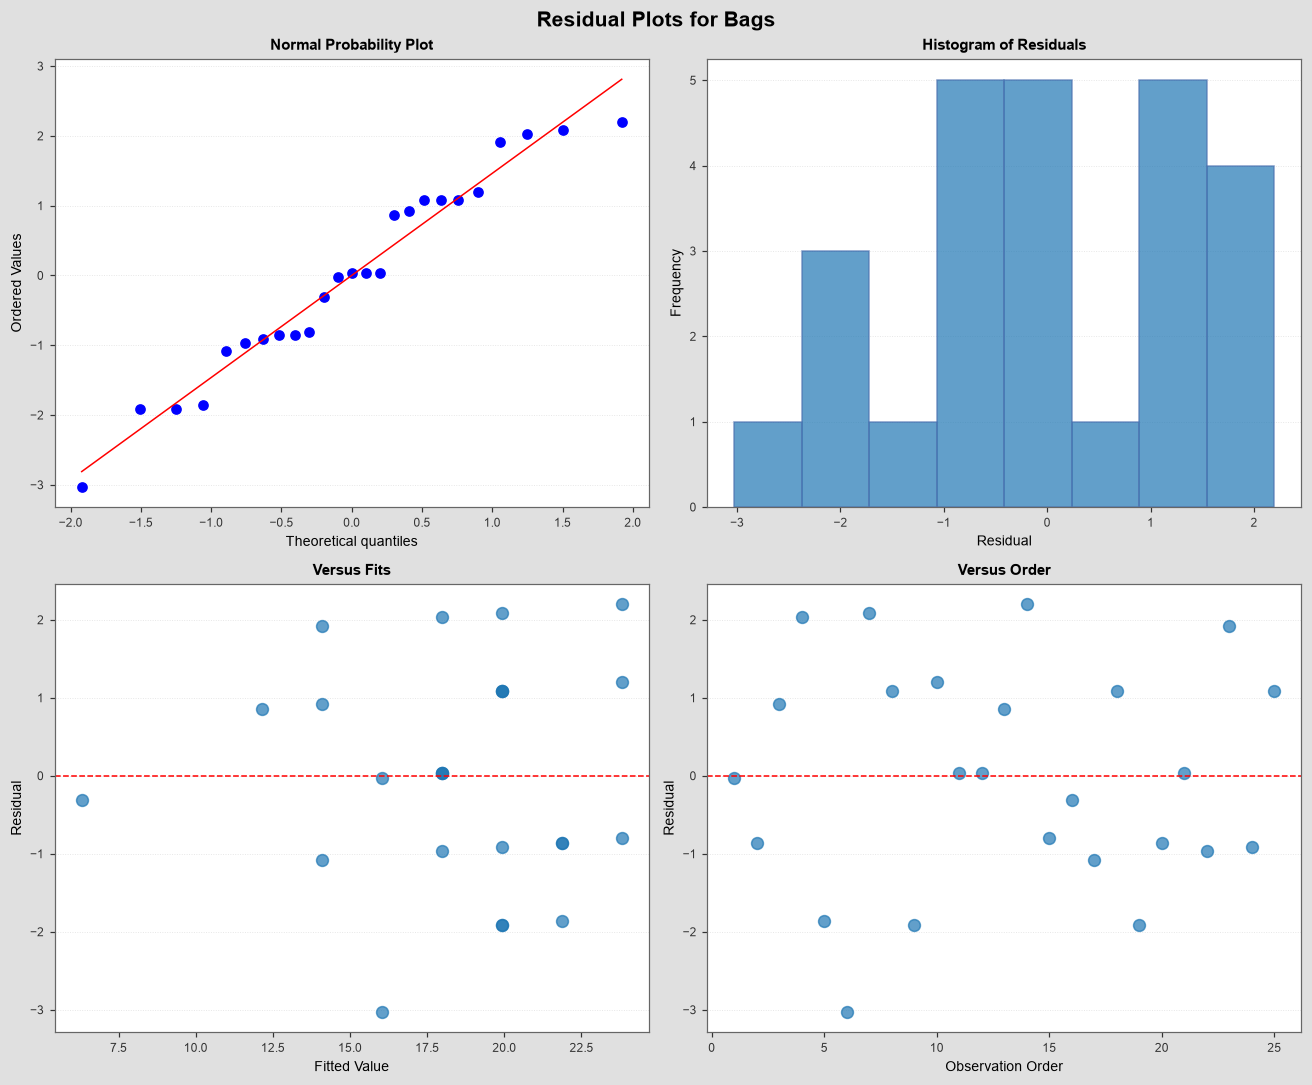

In [4]:
# Four-in-one residual plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Normal probability plot
stats.probplot(residuals, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')

# 2. Histogram
axes[0, 1].hist(residuals, bins=8, edgecolor=ms.HIST_EDGE, alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram of Residuals')

# 3. Versus Fits
axes[1, 0].scatter(fitted, residuals, alpha=0.7, s=60)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Versus Fits')

# 4. Versus Order
axes[1, 1].scatter(range(1, len(residuals)+1), residuals, alpha=0.7, s=60)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Versus Order')

plt.suptitle('Residual Plots for Bags', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Interpret the residual plots
print('RESIDUAL ANALYSIS')
print('=' * 60)
print()
print('Check 1: Are the residuals normally distributed?')
print('-' * 40)
print('  Look at the Normal Probability Plot.')
print('  The points follow a straight line → YES, they are normal.')
print()
print('Check 2: Any outliers or irregularities?')
print('-' * 40)
print('  Look at the Versus Fits and Versus Order plots.')
print('  No obvious outliers or patterns → NO irregularities.')
print()
print('CONCLUSION:')
print('  The assumptions are satisfied.')
print('  We can TRUST the conclusions from our regression analysis.')

RESIDUAL ANALYSIS

Check 1: Are the residuals normally distributed?
----------------------------------------
  Look at the Normal Probability Plot.
  The points follow a straight line → YES, they are normal.

Check 2: Any outliers or irregularities?
----------------------------------------
  Look at the Versus Fits and Versus Order plots.
  No obvious outliers or patterns → NO irregularities.

CONCLUSION:
  The assumptions are satisfied.
  We can TRUST the conclusions from our regression analysis.


---

## What if Assumptions Are Violated?

What if we had different residuals like these?

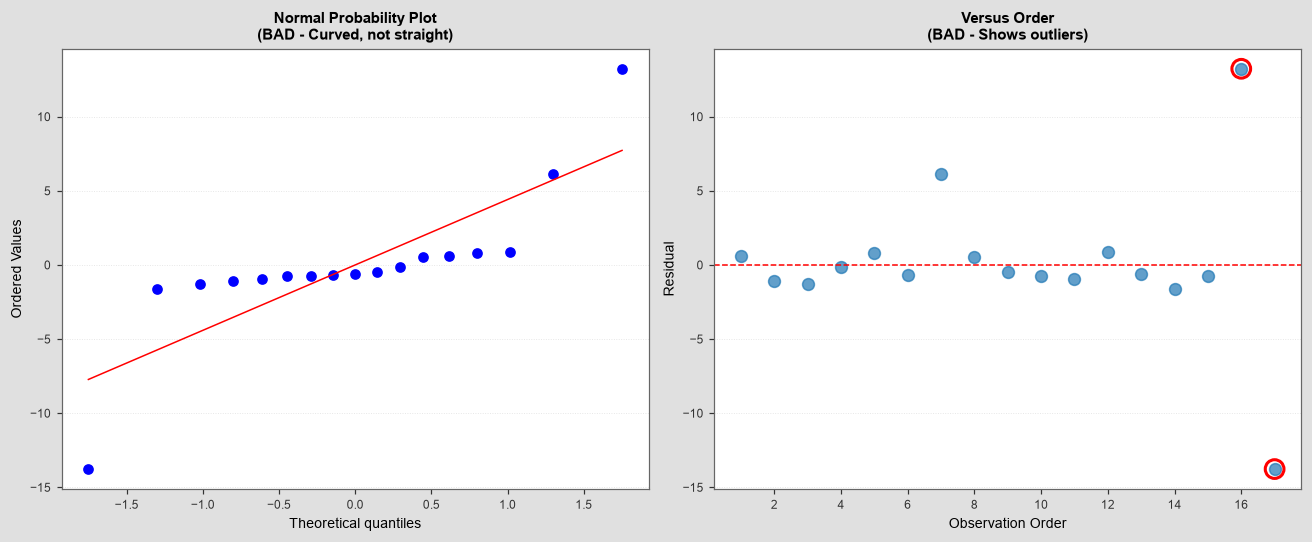

PROBLEMS IDENTIFIED:

1. Normal Probability Plot shows a CURVED line instead of straight
   → Residuals are NOT normally distributed

2. The graph shows a few OUTLIERS (circled in red)

In such cases, conclusions from regression should be treated with CAUTION.


In [6]:
# Example of BAD residuals (for illustration)
np.random.seed(123)

# Create non-normal residuals with outliers
bad_residuals = np.concatenate([
    np.random.exponential(2, 15),  # Skewed distribution
    [15, -12]  # Outliers
])
bad_residuals = bad_residuals - bad_residuals.mean()  # Center around 0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bad probability plot
stats.probplot(bad_residuals, dist="norm", plot=axes[0])
axes[0].set_title('Normal Probability Plot\n(BAD - Curved, not straight)')

# Bad versus order with outliers
axes[1].scatter(range(1, len(bad_residuals)+1), bad_residuals, alpha=0.7, s=60)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Observation Order')
axes[1].set_ylabel('Residual')
axes[1].set_title('Versus Order\n(BAD - Shows outliers)')

# Highlight outliers
outlier_idx = [16, 17]  # Last two points
for idx in outlier_idx:
    axes[1].scatter(idx, bad_residuals[idx-1], s=150, facecolors='none', 
                    edgecolors='red', linewidths=2)

plt.tight_layout()
plt.show()

print('PROBLEMS IDENTIFIED:')
print()
print('1. Normal Probability Plot shows a CURVED line instead of straight')
print('   → Residuals are NOT normally distributed')
print()
print('2. The graph shows a few OUTLIERS (circled in red)')
print()
print('In such cases, conclusions from regression should be treated with CAUTION.')

---

## Solutions When Assumptions Are Violated

Depending on what the violation of assumptions are, you can try different things:

| Problem | Possible Solution |
|---------|------------------|
| **Outliers** | Delete them and see if results change a lot. Compare your model under both situations. |
| **Non-linearity** | Try a quadratic regression model (discussed in next video) |

Regression analysis can be easily extended to deal with many different situations, but that is a topic outside of the scope of this video series.

---

## Summary

### Residual Analysis (Step 3 of Regression)

You learned to perform a **residual check** for your regression analysis.

### What to Check

| Check | How to Verify |
|-------|---------------|
| Normally distributed? | Normal probability plot should be a straight line |
| No outliers/irregularities? | Versus Fits and Versus Order plots should show no patterns |

### Interpretation

- If assumptions are **met** → You can trust your regression conclusions
- If assumptions are **not met** → Be careful to interpret your results